# 12 计算性能

## 12.1 编译器和解释器

**命令式编程（imperative programming）** 如 Python 、 C ，指通过代码告诉计算机如何做、逐步更改程序的状态的编程语言。 

**解释型语言（Interpreted Language）** 指代码不需要预先编译成机器码，而是由解释器逐行读取、分析并执行的编程语言。

这两个概念分别描述了编程范式和执行方式上的某个类别。

命令式编程方便但是效率不高，逐步更改程序的状态会存在某个函数被重复调用的情况，在一个或多个GPU上执行命令的开销可能会非常大，而且还需要保存所有变量值，以防止后续可能会用到。

**符号式编程（symbolic programming）** 与命令式编程对应， **先构建计算表达式/计算图** ，然后再 **一次性执行** 整个表达式的编程范式。

命令式（解释型）编程和符号式编程的区别如下：

- 命令式编程更容易使用。在Python中，命令式编程的大部分代码都是简单易懂的。命令式编程也更容易调试，这是因为无论是获取和打印所有的中间变量值，或者使用Python的内置调试工具都更加简单；
- 符号式编程运行效率更高，更易于移植。符号式编程更容易在编译期间优化代码，同时还能够将程序移植到与Python无关的格式中，从而允许程序在非Python环境中运行，避免了任何潜在的与Python解释器相关的性能问题。

**混合式编程** torchscript 允许用户使用纯命令式编程进行开发和调试, 同时能够将大多数程序转换为符号式程序。

`torch.jit.script()` 是 Pytorch 的 **即时编译工具** ，将 Python 代码转换为 torchscript 代码。它可以将一个神经网络作为参数，转换为新代码下的神经网络。

```python
def get_net():
    net = nn.Sequential(nn.Linear(512, 256),
        nn.ReLU(),
        nn.Linear(256, 128),
        nn.ReLU(),
        nn.Linear(128, 2))
    return net

x = torch.randn(size=(1, 512))
net = get_net()
net = torch.jit.script(net)
net(x)
```

这里的 `net` 是一个 `torch.jit.ScriptModule` 对象，调用 `.save()` 方法时，实际上调用了 `torch.jit.save()` 的快捷方式 `torch.jit.ScriptModule.save()` 方法。这可以将模型及其参数序列化保存到磁盘。



## 12.2 异步计算

**异步编程（Asynchronous Programming）** 是一种不阻塞程序执行的编程范式，允许在等待某些耗时操作（如I/O操作、网络请求）完成时，程序可以继续执行其他任务。

Pytorch 程序的执行主要发生在 C++ 实现的后端，Python 前端线程不需要执行实际的计算：

1. 前端命令后端将任务插入队列
2. 后端从队列接收任务并执行
3. 后端将结果返回到前端

在异步编程下，这三个阶段可以存在某些时候的并行，如第二个阶段能囊括大部分的第一个阶段的时间，这样可以减少运行时间。

**Pytorch 支持异步编程。**




## 12.3 自动并行

深度学习框架会 **在后端自动构建计算图** ，然后选择性地并行执行多个不相互依赖的任务以提高速度。

在许多情况下，需要在不同的设备之间移动数据。例如执行分布式优化时，就需要移动数据来聚合多个加速卡上的梯度。

`tensor.to()` 和 `tensor.copy_()` 等函数中中可以设置 `non_blocking=True` ，这将允许非阻塞传输。 

## 12.4 硬件

参考课程《计算机组成结构》和另外的笔记《Linux_Learning》。

## 12.5 多GPU训练

- 按层分区：

    考虑本来需要在单个GPU上计算64个通道的问题，可以将问题分散到4个GPU，每个GPU生成16个通道的数据。这个策略用于处理显存非常小的GPU，当通道或单元的数量不太小时，使计算性能有良好的提升。可用的显存呈线性扩展，多个GPU能够处理不断变大的网络。这便是AlexNet当时考虑的设计。

- 数据并行：

    跨多个GPU对数据进行拆分，所有GPU尽管有不同的观测结果，但是执行着相同类型的工作，在完成每个小批量数据的训练之后，梯度在GPU上聚合。同步只需要在每个小批量数据处理之后进行，当其他梯度参数仍在计算时，完成计算的梯度参数就可以开始交换。而且，GPU的数量越多，小批量包含的数据量就越大，从而就能提高训练效率。但是，添加更多的GPU并不能让我们训练更大的模型。

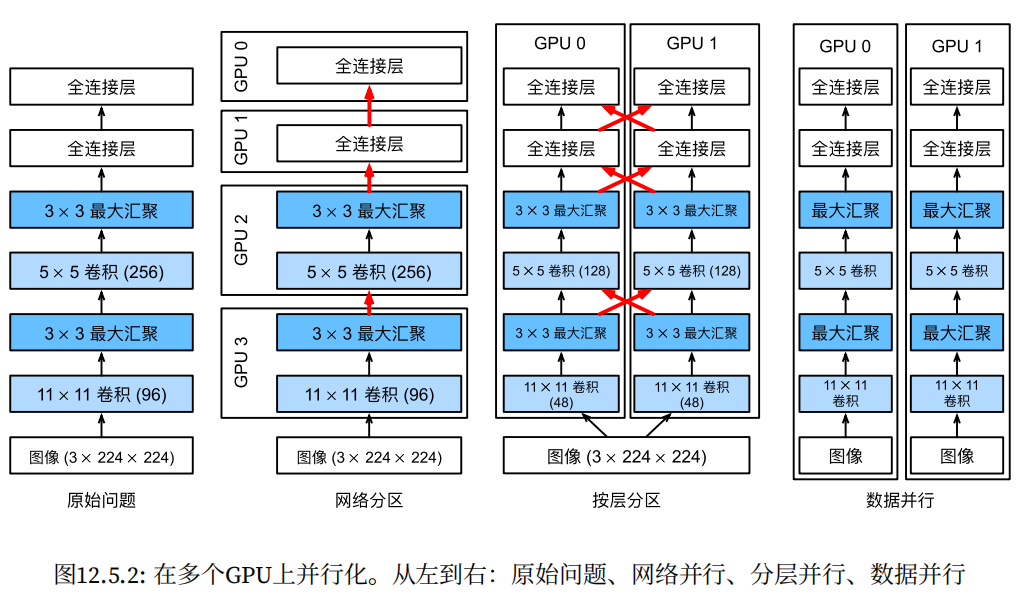

只要GPU的显存足够大，数据并行是最方便的：

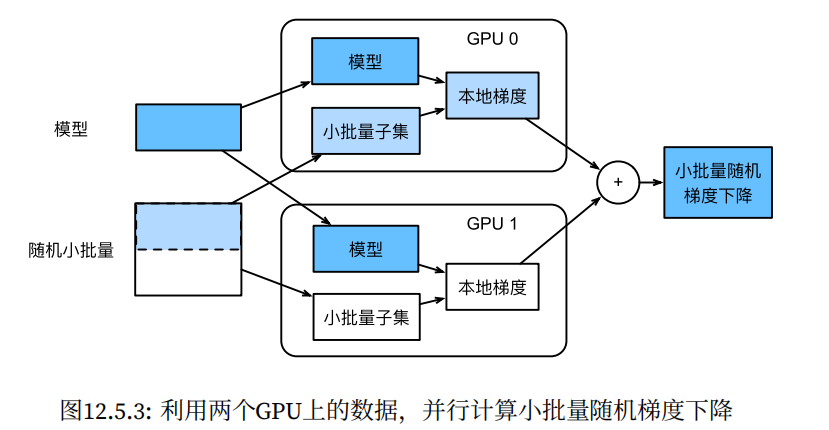

一般来说,  $k$ 个GPU并行训练过程如下:

- 在任何一次训练迭代中，给定的随机的小批量样本都将被分成 $k$ 个部分，并均匀地分配到GPU上
- 每个GPU根据分配给它的小批量子集，计算模型参数的损失和梯度
- 将 $k$ 个GPU中的局部梯度聚合，以获得当前小批量的随机梯度
- 聚合梯度被重新分发到每个GPU中
- 每个GPU使用这个小批量随机梯度，来更新它所维护的完整的模型参数集，即 **每个GPU更新梯度用的就是所有GPU中的局部梯度的平均** 

对于高效的多GPU训练，我们需要两个基本操作：向多个设备分发参数并附加梯度、跨多个设备对参数求和。在模型中，这些具体为自行编写的函数 `get_params()` 和 `allreduce()` 。

#### Pytorch 中的数据并行

- `nn.DataParallel()` ：最常用的多 GPU 训练封装， **自动将数据分发到多个 GPU 并汇总梯度** 

    ```python
    nn.DataParallel(
        module,          # 要并行化的模型
        device_ids=None, # GPU设备ID列表
        output_device=None, # 输出结果放在哪个GPU
        dim=0            # 数据分割的维度（默认0：batch维度）
    )
    ```

- `torch.device()` ：创建设备对象
- `.to(device)` ：张量/模型移动
- `toch.cuda` ：CUDA 设备管理



## 12.6 参数服务器

#### 数据并行训练


#### 环同步


#### 多机训练


#### 键值存储